# Experienments on different super pixel sizes

In [2]:
import torch
print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using torch 2.0.1+cu118
Using device: cuda


In [15]:

import os
import torch.nn as nn
from torch.nn import MSELoss
from torch.optim import Adam
from tqdm import tqdm 
import pandas as pd

class Simple_CNN(nn.Module):
    def __init__(self,p):
        super().__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(1,16,5,1,2),                              
            nn.ReLU(),            
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16,32,3,1,1),     
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                
        )
        self.conv3 = nn.Sequential(         
            nn.Conv2d(32,64,3,1,1),     
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                
        )
        self.mlp = nn.Sequential(
            nn.Dropout(p=p),
            nn.Linear(5*5*64,1024),
            nn.ReLU(),
            nn.Linear(1024,1024),
            nn.ReLU(),
            nn.Linear(1024,4),
        )
        
    def forward(self, x):
        y = self.conv1(x)
        y = self.conv2(y)
        y = self.conv3(y)
        y = y.view(y.size(0), -1)       
        y = self.mlp(y)
        return y
    
def train(model,X,y,optimizer,loss_fn,batchsize=5001):
    idx=np.arange(X.shape[0])
    np.random.shuffle(idx)
    
    epoch_loss = 0
    model.train()
    for i in range(0,X.shape[0],batchsize):
        if i+batchsize>=X.shape[0]:
            cur_idx=idx[i:]
        else:
            cur_idx=idx[i:i+batchsize]
            
        optimizer.zero_grad()
        y_pred = model(X[cur_idx])
        loss = loss_fn(y_pred, y[cur_idx])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()*cur_idx.shape[0]
    return epoch_loss/X.shape[0]
    
def evaluate(model,X,y,loss_fn,batchsize=5001,calc_MAE=False):
    epoch_loss = 0
    separate_loss=np.zeros(4,dtype=np.float32)
    MAEs=np.zeros(4,dtype=np.float32)
    model.eval()
    with torch.no_grad():
        for i in range(0,X.shape[0],batchsize):
            i_start=i
            if i+batchsize>=X.shape[0]:
                i_end=X.shape[0]-1
            else:
                i_end=i+batchsize
                
            y_pred=model(X[i_start:i_end])
            loss = loss_fn(y_pred, y[i_start:i_end])
            epoch_loss += loss.item()*(i_end-i_start)
            temp = torch.abs(y_pred-y[i_start:i_end])
            separate_loss += torch.sum(torch.square(temp),dim=0).to("cpu").numpy()
            MAEs += torch.sum(temp,dim=0).to("cpu").numpy()
            
        epoch_loss=epoch_loss/X.shape[0]
        separate_loss=separate_loss/X.shape[0]
        MAEs=MAEs/X.shape[0]
            
    return epoch_loss,separate_loss,MAEs


def run_cnn_exp(task_name,x_train,x_val,x_test,y_train,y_val,y_test,
                p=0.001,seed_list=[324,716,10086],n_epoch=1000,save_dir="./pixels_old/"):
    score=[]
    print("Running %s"%task_name)
    for seed in seed_list:
        torch.manual_seed(seed)
        model=Simple_CNN(p)
        model = model.to(device)
        loss_fn=MSELoss()
        optimizer=Adam(model.parameters(),lr=0.001)
        result=np.zeros((n_epoch//10,11),dtype=np.float32)
        
        first_stage=round(n_epoch*0.5)
        for i in range(first_stage):
            train_loss=train(model,x_train,y_train,optimizer,loss_fn)
            if i%10==0:
                j=i//10
                result[j,0]=train_loss
                result[j,1],_,_=evaluate(model,x_val,y_val,loss_fn)
                result[j,2],result[j,3:7],result[j,7:]=evaluate(model,x_test,y_test,loss_fn)
            print("(%d/%d)"%(i,n_epoch),end="\r")
        
        torch.save(model,save_dir+task_name+"_seed%d"%seed+".pt")
        #optimizer.param_groups[0]['lr'] = 0.0005
        for i in range(first_stage,n_epoch):
            train_loss=train(model,x_train,y_train,optimizer,loss_fn)
            if i%10==0:
                j=i//10
                result[j,0]=train_loss
                result[j,1],_,_=evaluate(model,x_val,y_val,loss_fn)
                result[j,2],result[j,3:7],result[j,7:]=evaluate(model,x_test,y_test,loss_fn)
                if np.min(result[:j,1])>result[j,1]:
                    torch.save(model,save_dir+task_name+"_seed%d"%seed+".pt")
            print("(%d/%d)"%(i,n_epoch),end="\r")
        
        best_idx=np.argmin(result[:,1])
        score.append(result[best_idx,2])
        result=pd.DataFrame(result,columns=["train_loss","validation_loss","test_loss","S0_loss","S1_loss","S2_loss","S3_loss",
                                           "S0_MAE","S1_MAE","S2_MAE","S3_MAE"])
        save_filename=save_dir+task_name+"_seed%d"%seed+".csv"
        result.to_csv(save_filename,index=False)
        print("\n")
    return score

In [16]:
from scipy.ndimage import zoom
from tqdm import tqdm
from math import pi

norm_factor=65536

def stokes_from_alphabeta(alpha,beta):
    alpha=alpha/180*pi
    beta=beta/180*pi
    result=np.zeros(3,dtype=np.float32)
    result[0]=0.5*(np.cos(4*alpha-4*beta)+np.cos(4*alpha))
    result[1]=0.5*(np.sin(4*alpha)-np.sin(4*alpha-4*beta))
    result[2]=-np.sin(4*alpha-2*beta)
    return result

def get_dataset(i_y,i_x,pixel_size=80,seed=1212):
    np.random.seed(seed)
    ori_y=np.zeros((1200,3),dtype=np.float32)
    fo=np.load("./dataset/alphabeta.npz")
    cur_alpha=fo["arr_0"]
    cur_beta=fo["arr_1"]
    for i in range(1200):
        ori_y[i]=stokes_from_alphabeta(cur_alpha[i],cur_beta[i])
    ori_x=np.zeros((1200,40,40),dtype=np.float32)
    for i in range(12):
        temp=np.load("./dataset/data%d.npz"%i)["arr_0"][:,y_anchor[i_y]:y_anchor[i_y]+80,x_anchor[i_x]:x_anchor[i_x]+80]
        for j in range(100):
            ori_x[i*100+j]=zoom(temp[j],(40/temp[j].shape[0],40/temp[j].shape[1]))

    shuffled_i=np.arange(1200)
    np.random.shuffle(shuffled_i)
    ori_y=ori_y[shuffled_i]
    ori_x=ori_x[shuffled_i]

    x_train=np.zeros((1000*10,1,40,40),dtype=np.float32)
    y_train=np.ones((1000*10,4),dtype=np.float32)
    y_train[:1000,1:]=ori_y[:1000]
    x_train[:1000,0]=ori_x[:1000]
    for i in range(1,10):
        temp=np.random.rand(1000).astype(np.float32)
        for j in range(1000):
            x_train[i*1000+j,0]=ori_x[j]*temp[j]
        y_train[i*1000:(i+1)*1000,0]=temp
        y_train[i*1000:(i+1)*1000,1:]=ori_y[:1000]
    x_val=np.zeros((100*10,1,40,40),dtype=np.float32)
    y_val=np.ones((100*10,4),dtype=np.float32)
    y_val[:100,1:]=ori_y[1000:1100]
    x_val[:100,0]=ori_x[1000:1100]
    for i in range(1,10):
        temp=np.random.rand(100).astype(np.float32)
        for j in range(100):
            x_val[i*100+j,0]=ori_x[1000+j]*temp[j]
        y_val[i*100:(i+1)*100,0]=temp
        y_val[i*100:(i+1)*100,1:]=ori_y[1000:1100]
    x_test=np.zeros((100*10,1,40,40),dtype=np.float32)
    y_test=np.ones((100*10,4),dtype=np.float32)
    y_test[:100,1:]=ori_y[1100:]
    x_test[:100,0]=ori_x[1100:]
    for i in range(1,10):
        temp=np.random.rand(100).astype(np.float32)
        for j in range(100):
            x_test[i*100+j,0]=ori_x[1100+j]*temp[j]
        y_test[i*100:(i+1)*100,0]=temp
        y_test[i*100:(i+1)*100,1:]=ori_y[1100:]
        
    np.random.seed(seed)
    aug_rand=np.random.rand(120)*1.5+1
    dark_img=np.load("./img/dark.npz")["arr_0"][y_anchor[i_y]:y_anchor[i_y]+80,x_anchor[i_x]:x_anchor[i_x]+80]
    x_aug=np.zeros((120,1,40,40),dtype=np.float32)
    for i in range(120):
        x_aug[i,0]=(zoom(dark_img,(40/80,40/80))*aug_rand[i]).astype(np.float32)
    x_train=np.concatenate((x_train,x_aug[:100]))
    x_val=np.concatenate((x_val,x_aug[100:110]))
    x_test=np.concatenate((x_test,x_aug[110:]))
    y_train=np.concatenate((y_train,np.zeros((100,4),dtype=np.float32)))
    y_val=np.concatenate((y_val,np.zeros((10,4),dtype=np.float32)))
    y_test=np.concatenate((y_test,np.zeros((10,4),dtype=np.float32)))
        
    x_train=torch.from_numpy((x_train/norm_factor).astype(np.float32)).to(device)
    x_val=torch.from_numpy((x_val/norm_factor).astype(np.float32)).to(device)
    x_test=torch.from_numpy((x_test/norm_factor).astype(np.float32)).to(device)
    y_train=torch.from_numpy(y_train).to(device)
    y_val=torch.from_numpy(y_val).to(device)
    y_test=torch.from_numpy(y_test).to(device)
    
    return x_train,x_val,x_test,y_train,y_val,y_test

def train_pixel(i_y,i_x,pixel_size=80,seed=1212):
    x_train,x_val,x_test,y_train,y_val,y_test=get_dataset(i_y,i_x,pixel_size,seed=seed)
    run_cnn_exp("y%d_x%d"%(i_y,i_x),x_train,x_val,x_test,y_train,y_val,y_test,
                seed_list=[seed])

# Post processing

In [2]:
import pandas as pd
import numpy as np
import os

sizes = [5,10,20,40,80,160]
dir_list = ["./different_size/%d/pixels"%i for i in [5,10,20,40,80,160]]
MAE_mean = np.zeros((len(sizes),4))
MAE_std = np.zeros((len(sizes),4))

for i in range(len(dir_list)):
    files = os.listdir(dir_list[i])
    cur_MAE = []
    for j in range(len(files)):
        cur_file = dir_list[i]+"/"+files[j]
        if cur_file.split(".")[-1] == "csv":
            table = pd.read_csv(cur_file)
            cur_MAE.append(table.iloc[np.argmin(table["validation_loss"]),-4:].values)
    cur_MAE = np.array(cur_MAE)
    MAE_mean[i] = np.mean(cur_MAE,0)
    MAE_std[i] = np.std(cur_MAE,0,ddof=1)


[0.00580205 0.02962565 0.0333237  0.02167478]
[0.00221449 0.0121313  0.01396864 0.00542084]


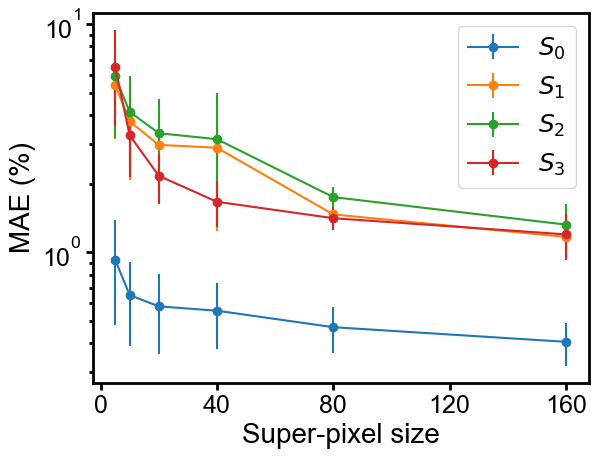

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial']


for i in range(4):
    plt.errorbar(sizes,MAE_mean[:,i]*100,yerr=MAE_std[:,i]*100,fmt="o-",label=r"$S_%d$"%i)
print(MAE_mean[2])
print(MAE_std[2])

plt.xlabel("Super-pixel size",fontsize=20)
plt.ylabel("MAE (%)",fontsize=20)
plt.legend(fontsize=18)
plt.xticks([0,40,80,120,160],fontsize=18)
plt.yticks(fontsize=18)
plt.yscale("log")

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

plt.savefig("size.svg",transparent=True,bbox_inches='tight')
plt.show()

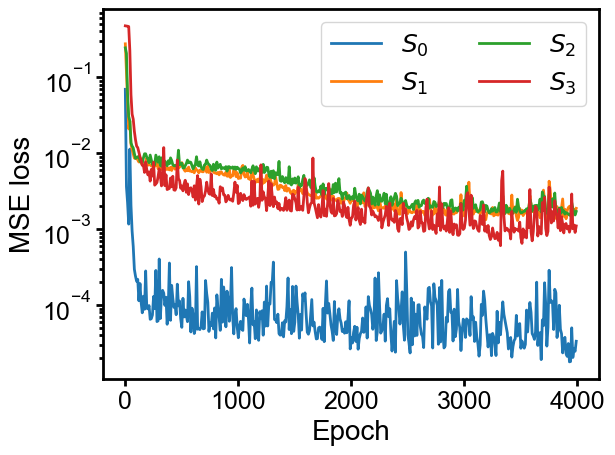

In [30]:
plt.rcParams['font.sans-serif'] = ['Arial']


np.random.seed(1212)
i1 = round(np.random.rand()*44)
table = pd.read_csv("./different_size/20/pixels/y%d_x%d_seed1212.csv"%(i1,i1))
x = np.arange(table.shape[0])*10
for i in range(4):
    plt.plot(x,table["S%d_loss"%i],lw=2,label=r"$S_%d$"%i)
    
plt.yscale("log")
plt.legend(fontsize=18,ncol=2)
plt.xticks([0,1000,2000,3000,4000],fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel("MSE loss",fontsize=20)
plt.xlabel("Epoch",fontsize=20)


bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

plt.savefig("learning_curve_sep.svg",transparent=True,bbox_inches='tight')
plt.show()

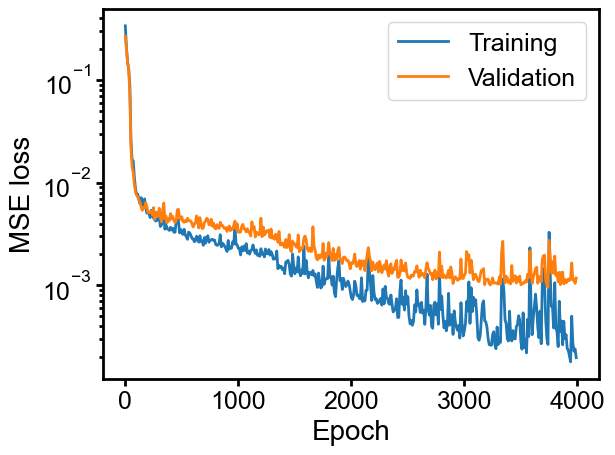

In [31]:
plt.plot(x,table["train_loss"],lw=2,label="Training")
plt.plot(x,table["test_loss"],lw=2,label="Validation")
plt.yscale("log")
plt.legend(fontsize=18,ncol=1)
plt.xticks([0,1000,2000,3000,4000],fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel("MSE loss",fontsize=20)
plt.xlabel("Epoch",fontsize=20)


bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

plt.savefig("learning_curve.svg",transparent=True,bbox_inches='tight')
plt.show()